In [2]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv(r"housing.csv")

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Split

In [7]:
df["income_cat"] = pd.cut(df["median_income"],
                           bins=[0 , 1.5 , 3 , 4.5 , 6 , np.inf ]  ,
                           labels=[1, 2 ,3 , 4 ,5])
                          

df["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1 , test_size=0.2 , random_state=42)

for train_index , test_index in split.split(df , df["income_cat"]):
    train_set = df.iloc[train_index]
    test_set = df.iloc[test_index]

### delete the `income_cat` column.

In [9]:
for set_ in (train_set , test_set):
    set_.drop("income_cat" , axis =1 , inplace = True)

C:\Users\2008e\AppData\Local\Temp\ipykernel_6468\88157955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat" , axis =1 , inplace = True)
C:\Users\2008e\AppData\Local\Temp\ipykernel_6468\88157955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat" , axis =1 , inplace = True)


In [10]:
housing = train_set.copy()

In [11]:
corr= housing.corr(numeric_only=True)
corr["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

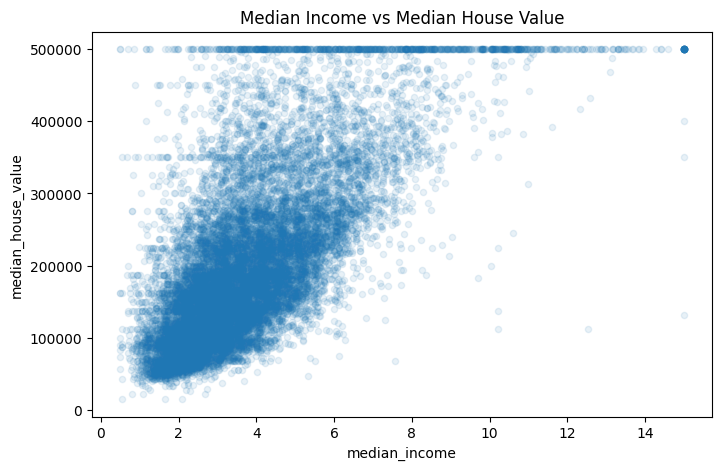

In [12]:
import matplotlib.pyplot as plt

housing.plot(kind = "scatter" , x = "median_income" , y = "median_house_value" , alpha = 0.1 , figsize = (8 , 5))

plt.title("Median Income vs Median House Value")
plt.show


In [16]:
train_set_clean = train_set[train_set["median_house_value"] < 500000]

In [33]:
x_train = train_set_clean.drop("median_house_value" , axis=1).copy()
y_train = train_set_clean["median_house_value"].copy()

x_test = test_set.drop("median_house_value" , axis=1).copy()
y_test = test_set["median_house_value"].copy()

In [34]:
x_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


In [35]:
from sklearn.base import BaseEstimator , TransformerMixin
rooms_ix , bedrooms_ix , population_ix , households_ix = 3 , 4 , 5 , 6 

class customtransformer (BaseEstimator , TransformerMixin):
    def __init__(self , add_bedrooms_per_room= True , add_population_per_household=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
        self.add_population_per_household = add_population_per_household


    def fit (self , X , y=None):
        return self
        
    def transform (self , X):
        rooms_per_household = X[: , rooms_ix] / X[: , households_ix]
        x_modified = np.c_[X , rooms_per_household]

        if self.add_bedrooms_per_room: 
            bedrooms_per_room = X[: , bedrooms_ix] / X[: , rooms_ix]
            x_modified = np.c_[x_modified , bedrooms_per_room]

        if self.add_population_per_household:
            population_per_household = X[: , population_ix] / X[: , households_ix]
            x_modified = np.c_[x_modified , population_per_household]

        return x_modified           


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer , make_column_selector

num_pipeline = Pipeline([
             
                 ("imputer" , SimpleImputer(strategy="median")),
                 ('attribs_adder' , customtransformer()),
                 ("scaler" , StandardScaler())   ,
])


cat_pipeline = Pipeline([
                
                ('imputer' , SimpleImputer(strategy="most_frequent")),
                ("encoder" , OneHotEncoder(handle_unknown="ignore")),
])


full_pipeline = ColumnTransformer([
                           
                           ("num" , num_pipeline , make_column_selector(dtype_include=np.number)),
                           ("cat" , cat_pipeline , make_column_selector(dtype_include=[object, "category"])),
])


x_train_prepared = full_pipeline.fit_transform(x_train)
x_test_prepared = full_pipeline.transform(x_test)


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

linear = LinearRegression()
linear.fit(x_train_prepared , y_train)

linear_prediction = linear.predict(x_train_prepared)

linear_mse = mean_squared_error(y_train , linear_prediction)
linear_rmse = np.sqrt(linear_mse)
print("linear regression rmse = " , linear_rmse)

#==============================================================================

tree = DecisionTreeRegressor(random_state=42)
tree.fit(x_train_prepared , y_train)

tree_prediction = tree.predict(x_train_prepared)

tree_mse = mean_squared_error(tree_prediction , y_train)
tree_rmse = np.sqrt(tree_mse)
print("decision tree rmse = " , tree_rmse) 

#==============================================================================

forest = RandomForestRegressor(n_estimators=100 , random_state=42 )
forest.fit(x_train_prepared , y_train)

forest_prediction = forest.predict(x_train_prepared)

forest_mse = mean_squared_error(forest_prediction , y_train)
forest_rmse = np.sqrt(forest_mse)

print ("random forest rmse = " , forest_rmse)

linear regression rmse =  60003.59319121533
decision tree rmse =  0.0
random forest rmse =  16784.77192346105


## Cross validation.

In [42]:
from sklearn.model_selection import cross_val_score

def display_scores (scores , model_name): 
    rmse_score = np.sqrt(-scores)
    print(f"==== {model_name} ====")
    print(f"scores (10) : {np.round(rmse_score , 2)}")
    print(f"std : {rmse_score.std() }" )
    print("mean : " + "{:.2f}".format(rmse_score.mean()))
    

In [43]:
linear_score = cross_val_score(linear , x_train_prepared , y_train , scoring = "neg_mean_squared_error" , cv=10)
display_scores(linear_score , "linear regresion")
 
#==============================================================================

tree_score = cross_val_score(tree , x_train_prepared , y_train , scoring="neg_mean_squared_error" , cv=10)
display_scores(tree_score , "decision tree" )

#==============================================================================

forest_score = cross_val_score(forest , x_train_prepared , y_train , scoring="neg_mean_squared_error" , cv=10)
display_scores(forest_score , "random forest")


==== linear regresion ====
scores (10) : [61023.7  56364.13 59663.73 61213.92 59616.08 63160.17 65257.83 62249.66
 56400.93 59218.6 ]
std : 2655.5603711124295
mean : 60416.87
==== decision tree ====
scores (10) : [61931.36 63738.76 63580.43 63942.31 64353.13 68383.44 65710.78 62614.71
 63483.65 65229.39]
std : 1720.7287921732777
mean : 64296.80
==== random forest ====
scores (10) : [44263.5  44660.9  42995.46 46707.97 44116.03 46316.77 46035.19 46844.88
 43495.05 46108.48]
std : 1335.6038774110611
mean : 45154.42
